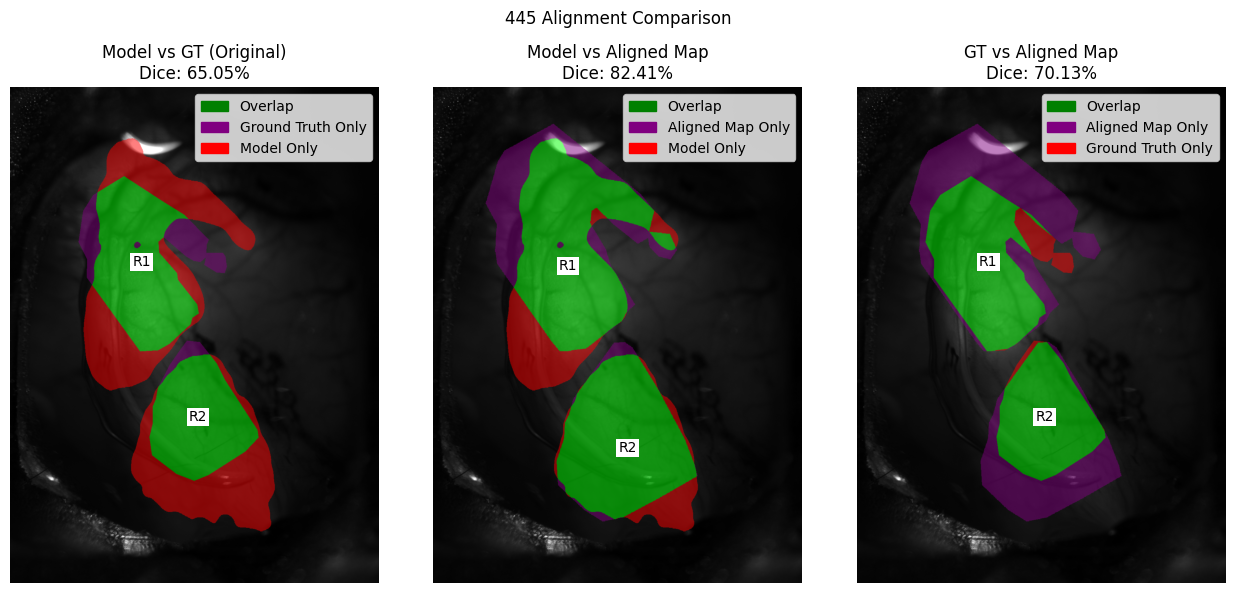

Elapsed: 2.97 s | Reg Dice: 67.41, 74.19


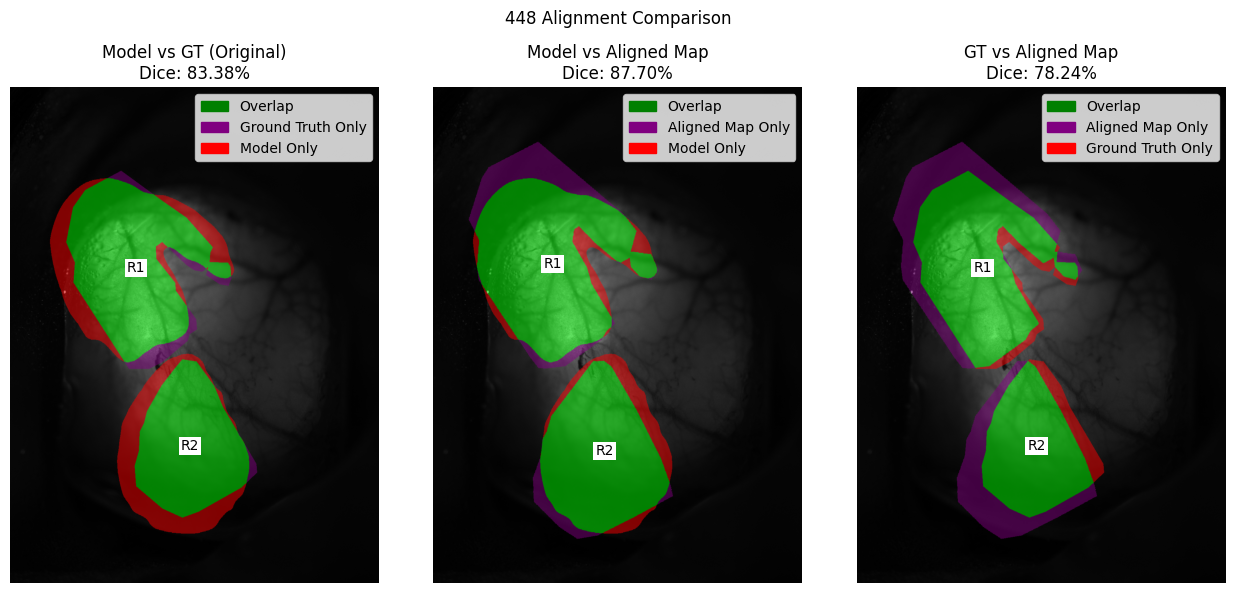

Elapsed: 3.04 s | Reg Dice: 79.51, 76.35


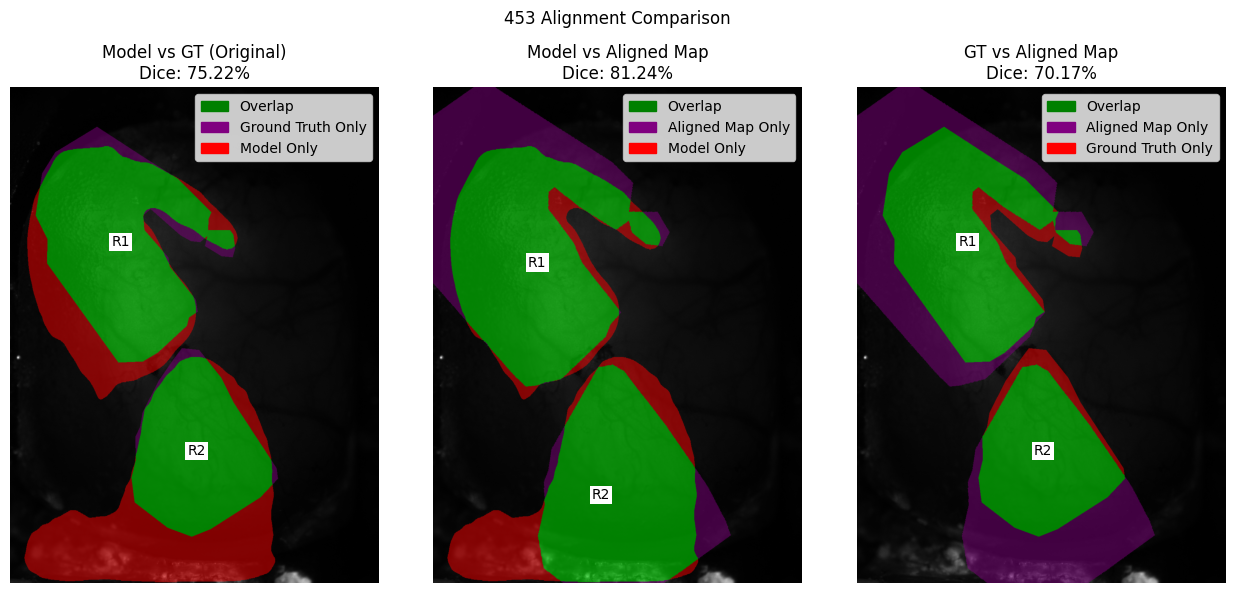

Elapsed: 3.02 s | Reg Dice: 70.68, 69.42


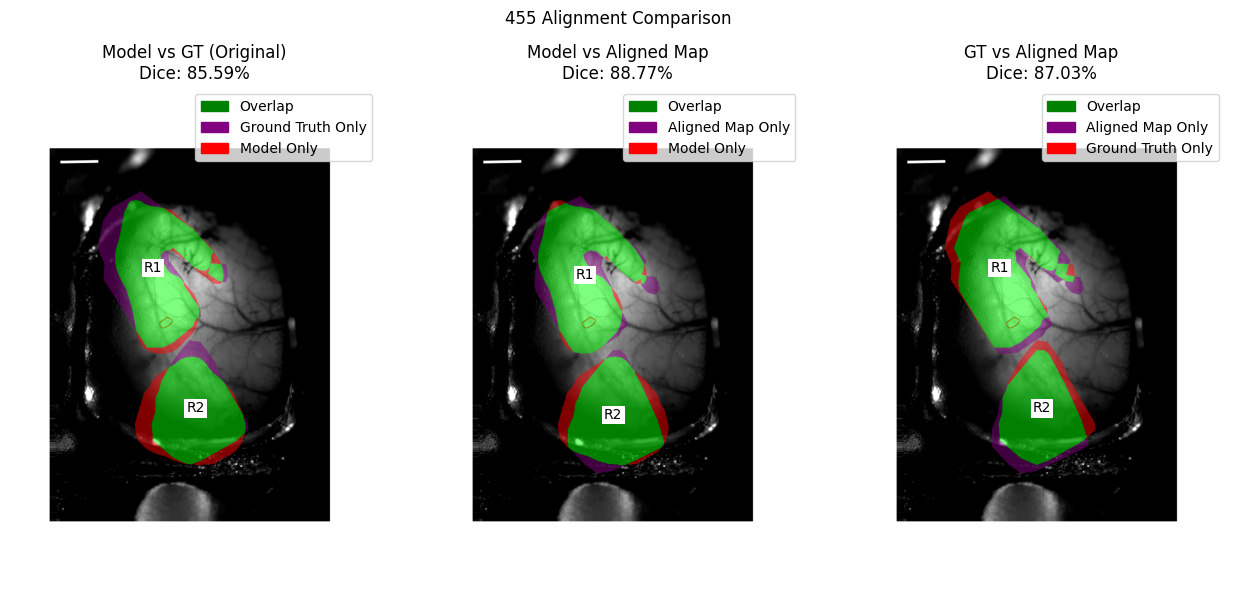

Elapsed: 3.19 s | Reg Dice: 88.19, 85.30


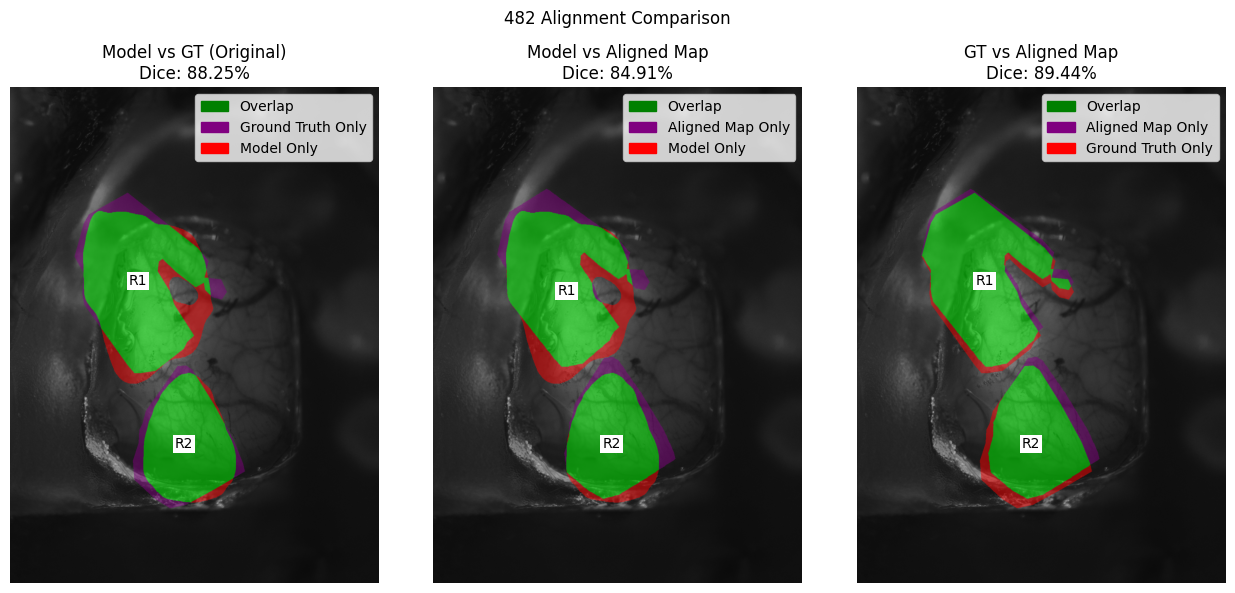

Elapsed: 2.98 s | Reg Dice: 91.64, 86.15


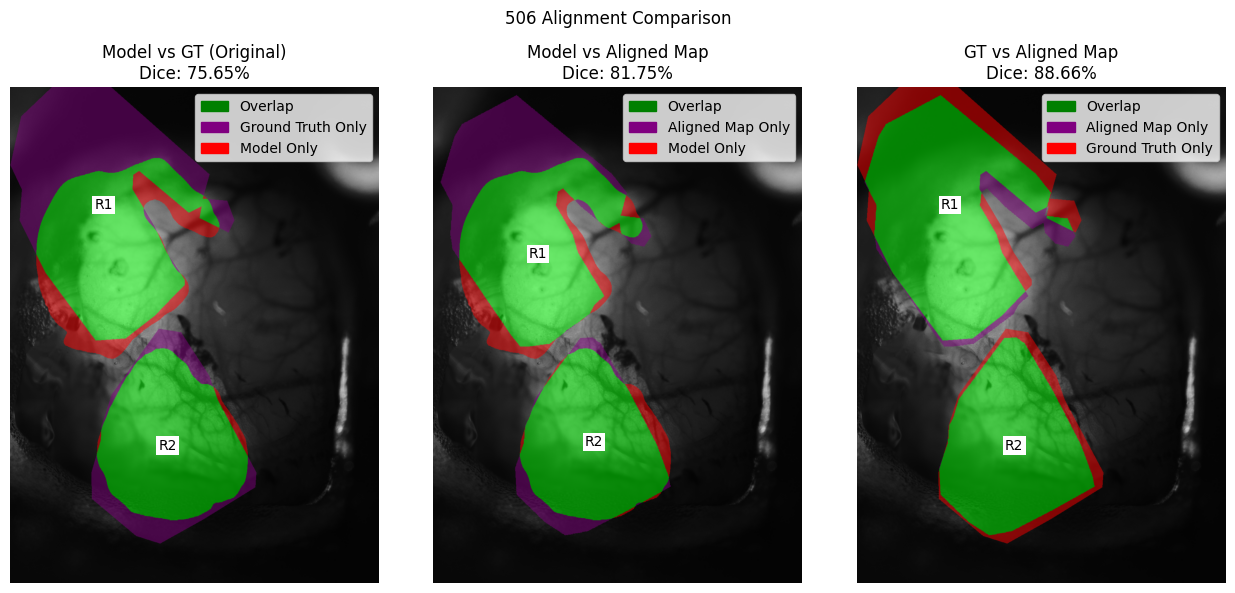

Elapsed: 3.07 s | Reg Dice: 85.85, 92.80


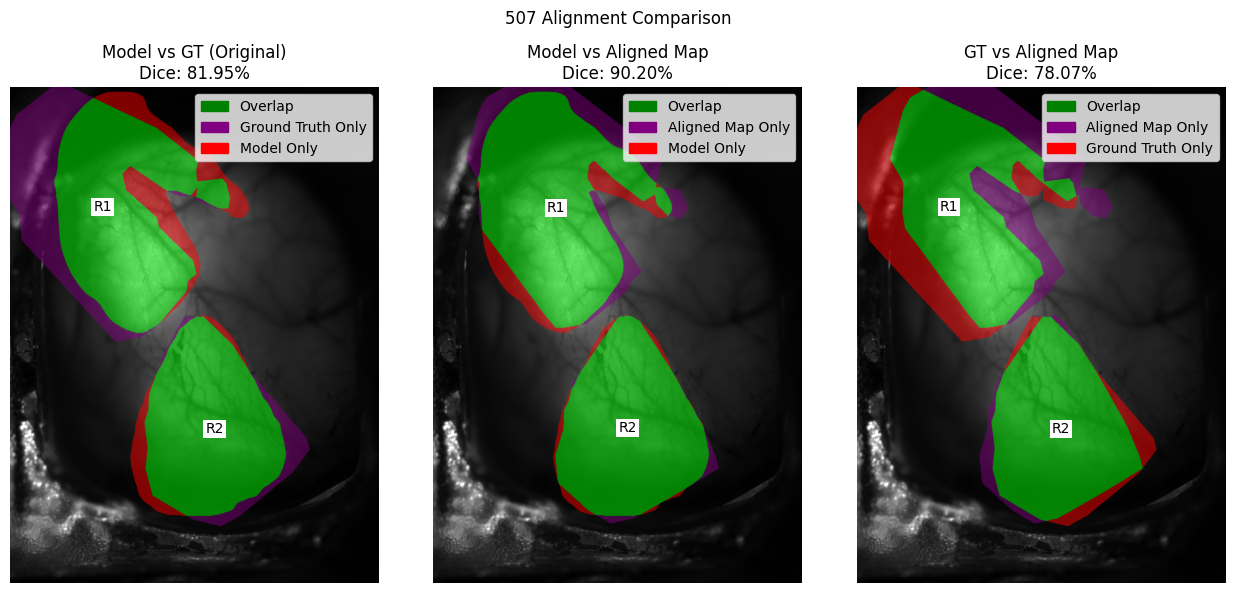

Elapsed: 3.03 s | Reg Dice: 68.83, 91.57


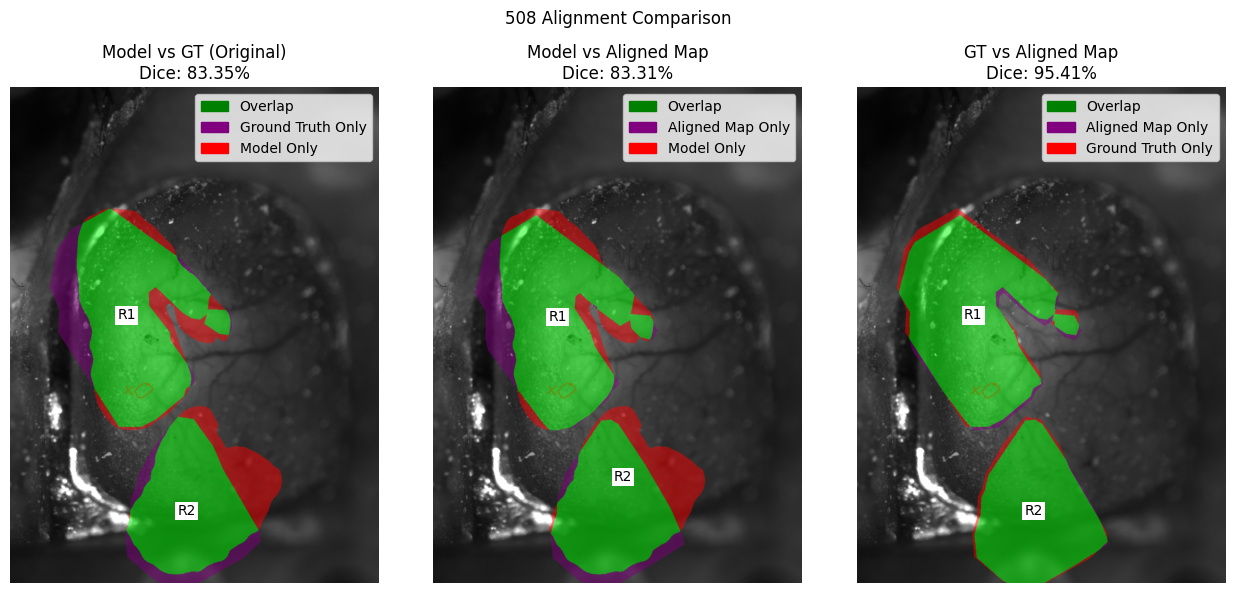

Elapsed: 3.06 s | Reg Dice: 94.32, 97.04


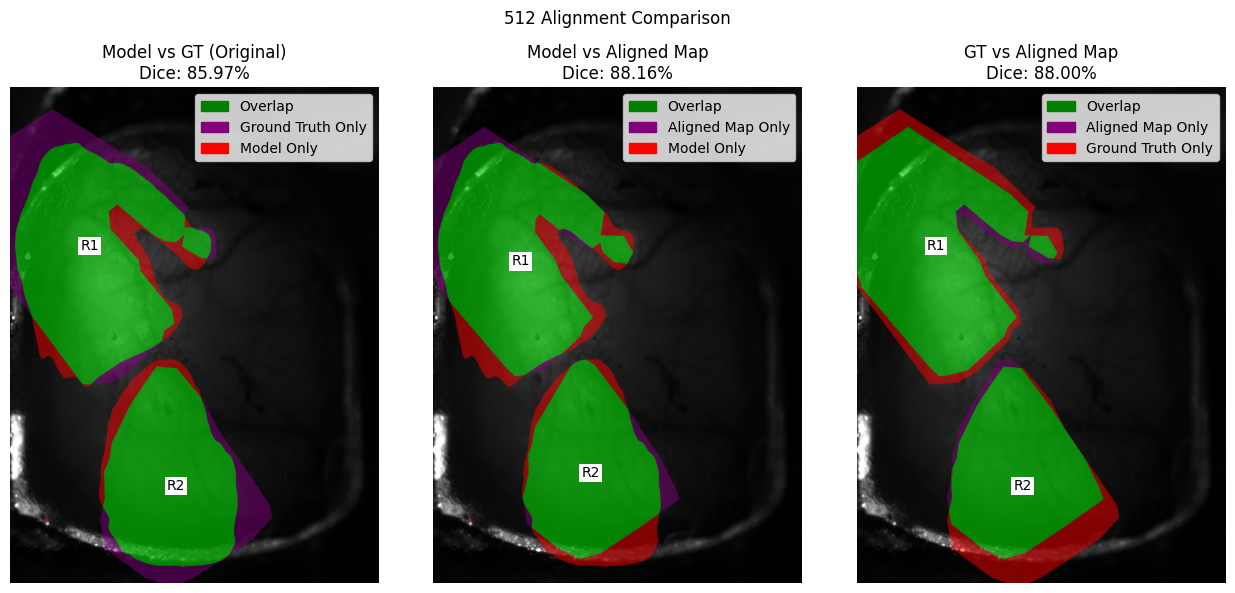

Elapsed: 3.11 s | Reg Dice: 89.59, 85.76


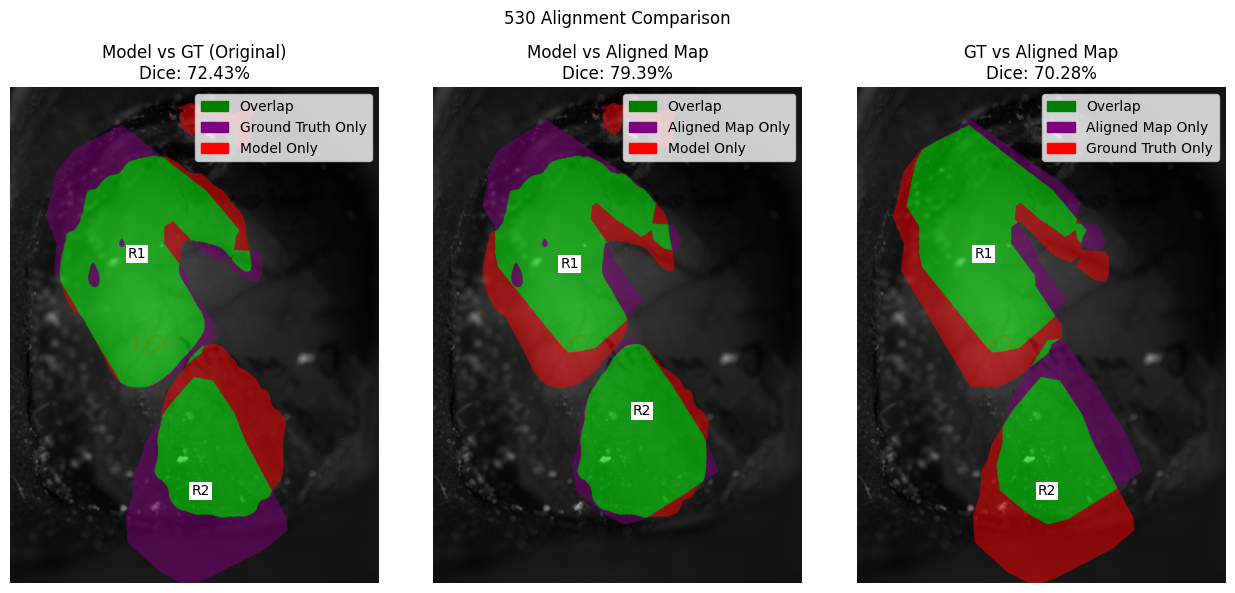

Elapsed: 3.05 s | Reg Dice: 77.02, 59.33


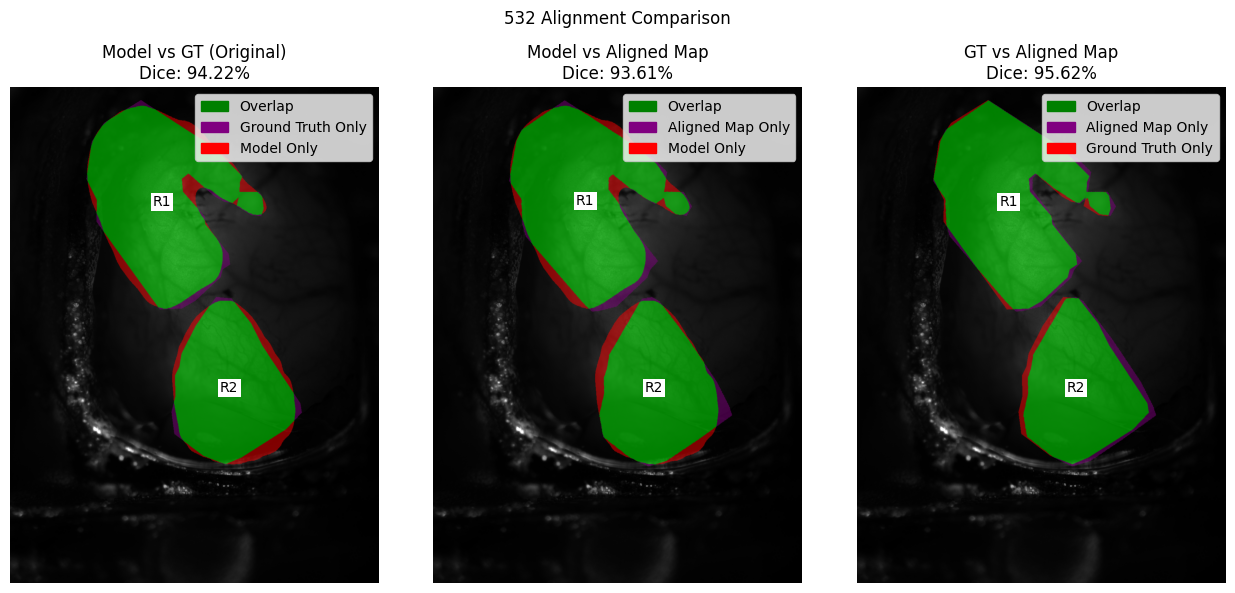

Elapsed: 3.02 s | Reg Dice: 97.02, 93.53


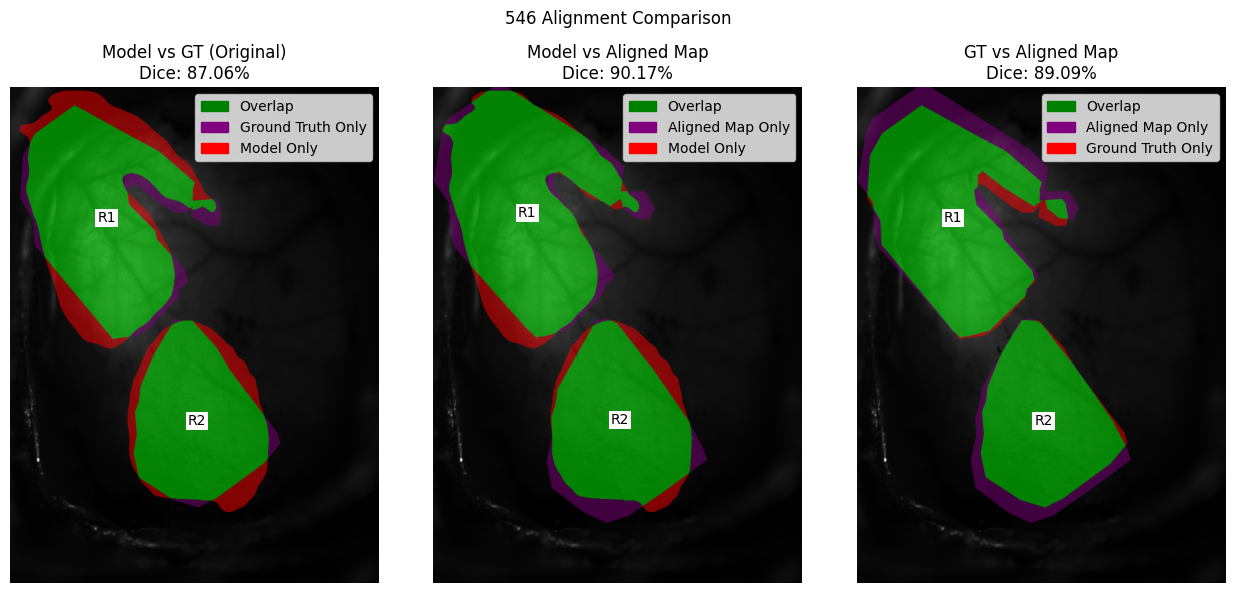

Elapsed: 3.05 s | Reg Dice: 87.64, 91.25


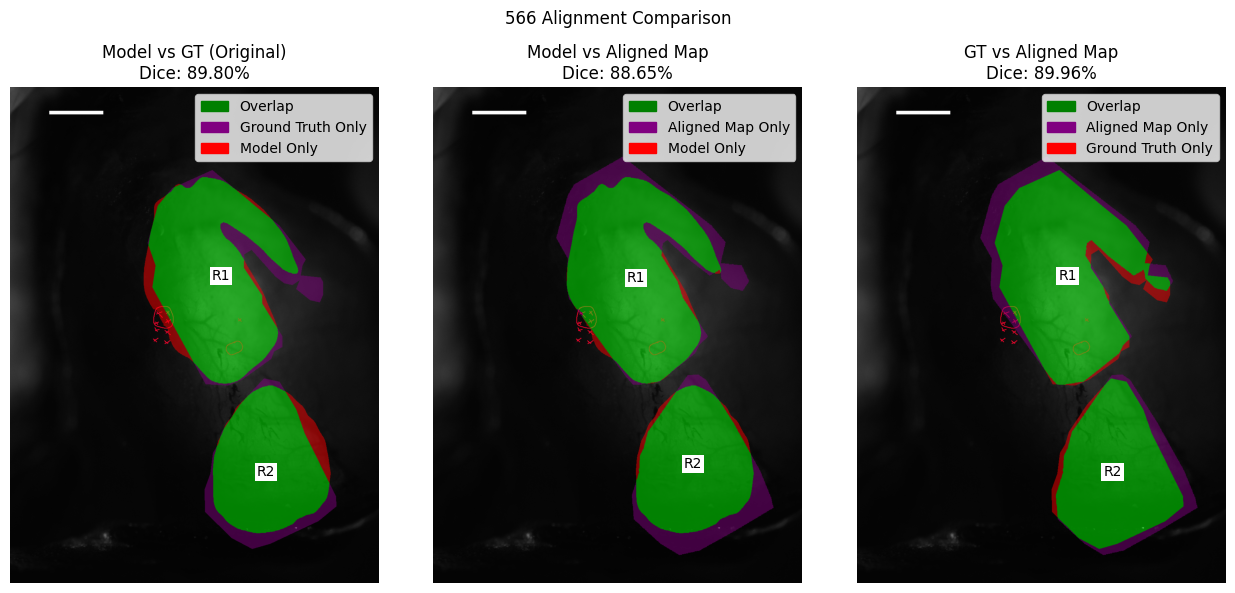

Elapsed: 3.07 s | Reg Dice: 89.25, 91.03


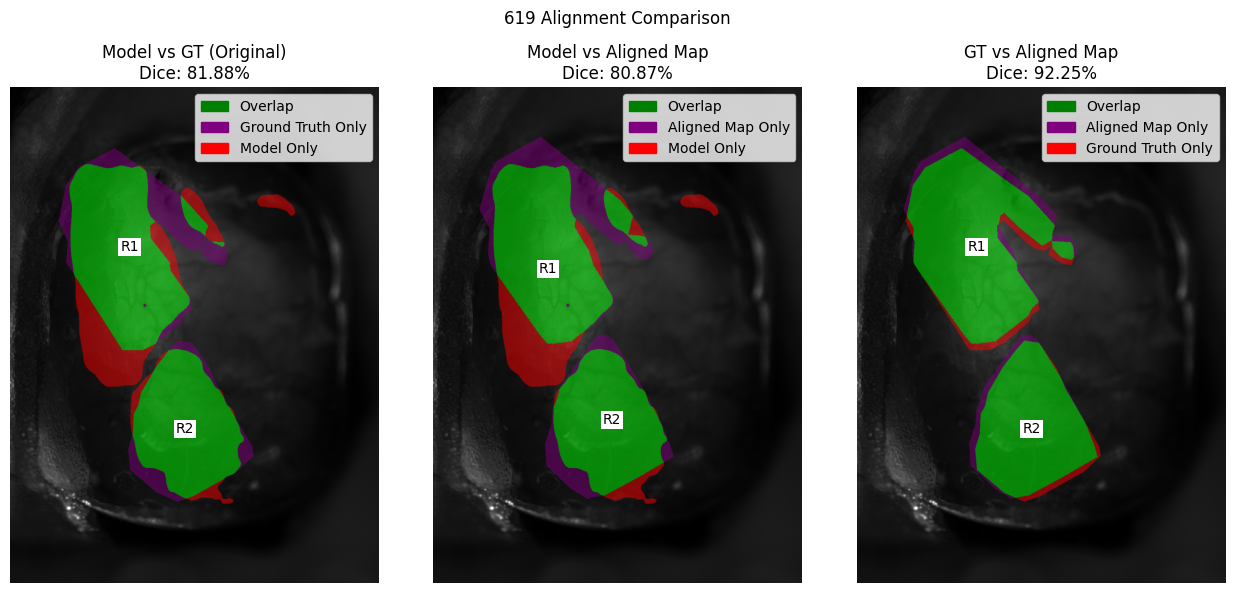

Elapsed: 3.41 s | Reg Dice: 91.12, 93.94


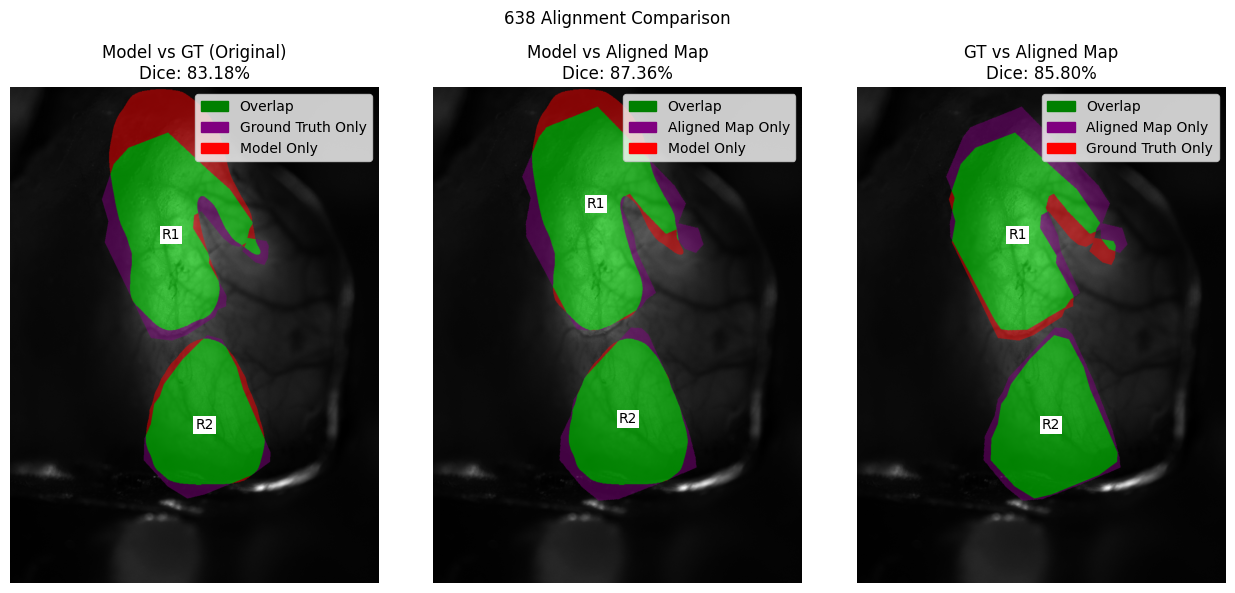

Elapsed: 3.04 s | Reg Dice: 81.12, 92.76


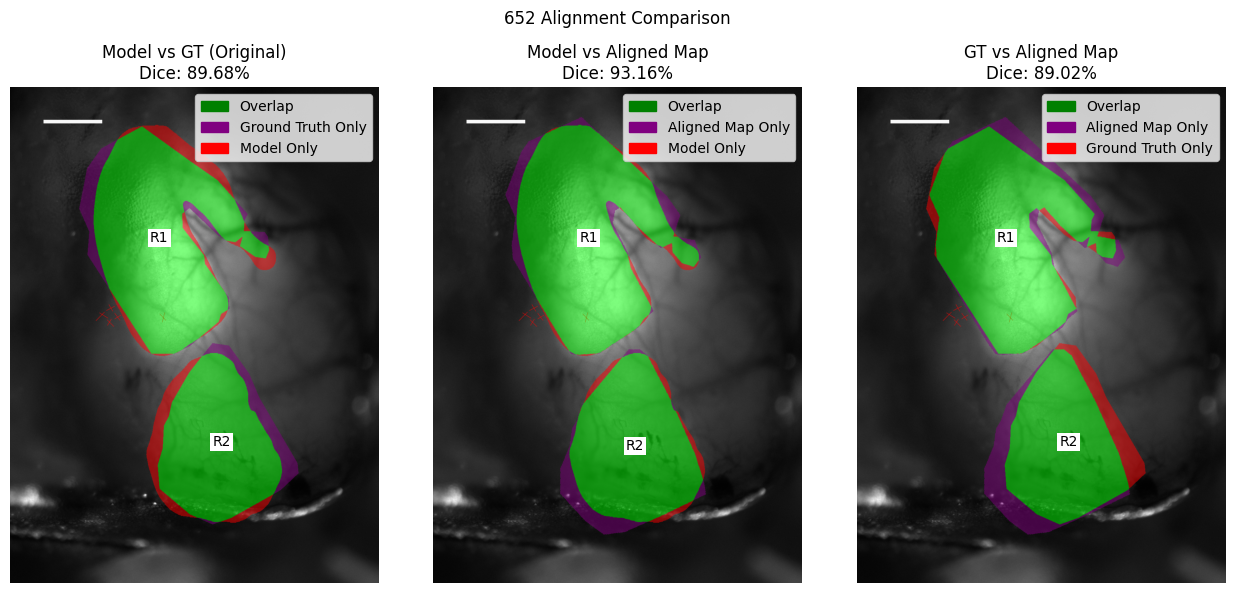

Elapsed: 3.02 s | Reg Dice: 92.95, 83.17


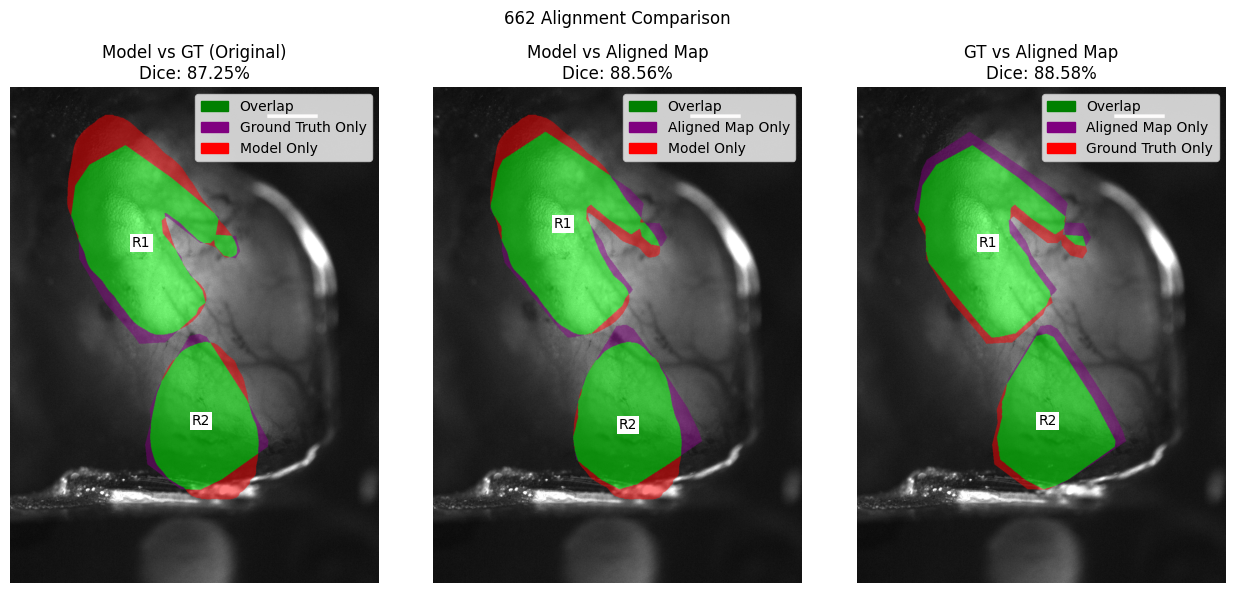

Elapsed: 3.19 s | Reg Dice: 87.03, 90.91


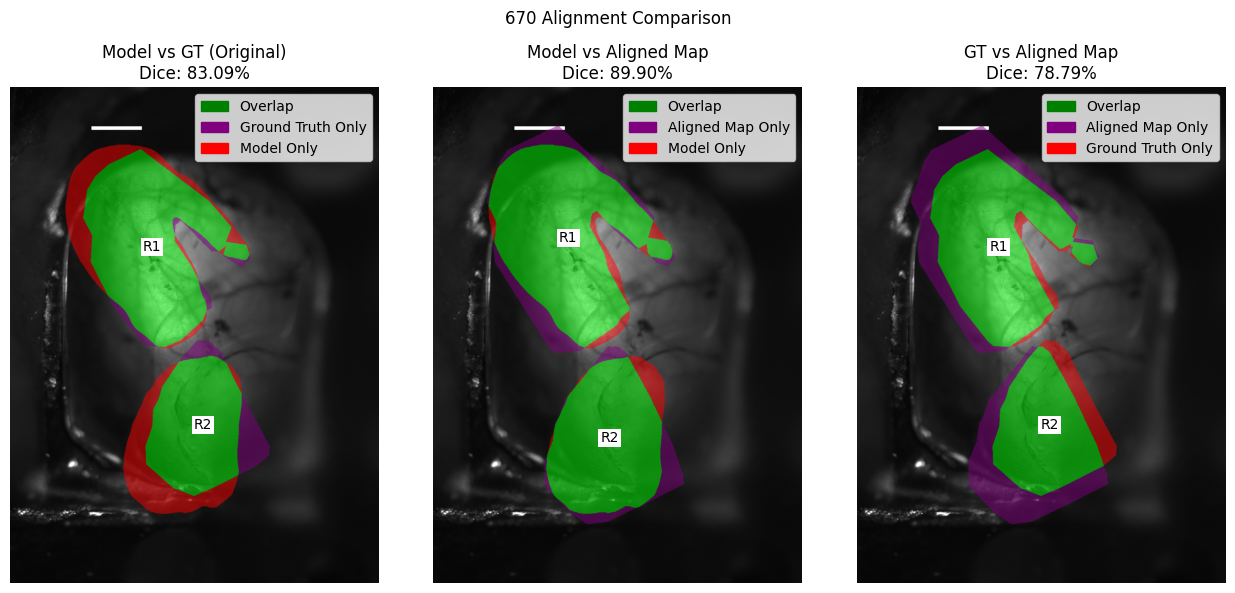

Elapsed: 3.16 s | Reg Dice: 82.97, 72.53


In [52]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
from time import time

gt_for_alignment = Path(r"C:\Users\Nolan\Documents\Python Scripts\ECE 549\final\gradient accumulation\base_gt_482.png")
red, green = ((0,0,120),(90,90,255)), ((0,120,0),(90,255,90))

def ld(p):
    i = cv.imread(str(p))
    if i is None: 
        print(f'Error reading: {p}')
        return None, None, None
    return (cv.inRange(i,red[0],red[1])>0).astype(np.uint8), (cv.inRange(i,green[0],green[1])>0).astype(np.uint8), i

def wrp(m, c, a, s, t):
    M = cv.getRotationMatrix2D(c, a, s); M[:,2] += t
    return cv.warpAffine(m, M, m.shape[:2][::-1], flags=0), M

def fit(p1, p2, g1, g2):
    pU, gU = p1|p2, g1|g2
    s, a, x, y = np.sqrt((gU.sum()+1e-9)/(pU.sum()+1e-9)), 0, 0, 0
    P1, P2, PU, G1, G2, GU = [p1], [p2], [pU], [g1], [g2], [gU]
    for _ in range(3): 
        for l in [P1, P2, PU, G1, G2, GU]: l.append(cv.pyrDown(l[-1]))
    
    for i in range(4):
        if i: x, y = x*2, y*2
        c = (PU[3-i].shape[1]/2, PU[3-i].shape[0]/2)
        sp, rp = [(0.3,11),(0.15,9),(0.06,9),(0.03,7)][i], [(20,21),(10,17),(4,13),(2,9)][i]
        
        for mode in [0, 1]:
            best = (-float('inf'), s, a, x, y)
            rng = np.linspace(s*(1-sp[0]), s*(1+sp[0]), sp[1]) if mode==0 else np.linspace(a-rp[0], a+rp[0], rp[1])
            for v in rng:
                ts, ta = (v, a) if mode==0 else (s, v)
                wU, _ = wrp(PU[3-i], c, ta, ts, (x, y))
                (dx, dy), _ = cv.phaseCorrelate(wU.astype(np.float32), GU[3-i].astype(np.float32))
                w1, _ = wrp(P1[3-i], c, ta, ts, (x+dx, y+dy))
                w2, _ = wrp(P2[3-i], c, ta, ts, (x+dx, y+dy))
                # Union Score (matches notebook logic for alignment)
                # Cast sums to float to prevent uint overflow during subtraction
                s1, s2 = float((w1&G1[3-i]).sum()), float((w2&G2[3-i]).sum())
                d1, d2 = float((w1^G1[3-i]).sum()), float((w2^G2[3-i]).sum())
                u = float(((w1|w2)&(G1[3-i]|G2[3-i])).sum())
                val = (2*s1 - 10*d1) + (2*s2 - 10*d2) + (12*u)
                
                if val > best[0]: best = (val, ts, ta, x+dx, y+dy)
            s, a, x, y = best[1:]
    return s, a, x, y

def overlay(img, v_mask, m_mask):
    out = img.copy()
    # Green (Overlap)
    ov = (v_mask & m_mask) > 0
    out[ov] = (out[ov]*0.5 + np.array([0,255,0])*0.5).astype(np.uint8)
    # Purple (Vector/Primary Only)
    v_only = (v_mask & ~m_mask) > 0
    out[v_only] = (out[v_only]*0.5 + np.array([128,0,128])*0.5).astype(np.uint8)
    # Red (Model/Secondary Only)
    m_only = (m_mask & ~v_mask) > 0
    out[m_only] = (out[m_only]*0.5 + np.array([255,0,0])*0.5).astype(np.uint8)
    return out

def get_centroid(mask):
    M = cv.moments(mask)
    return (int(M['m10']/M['m00']), int(M['m01']/M['m00'])) if M['m00'] > 0 else None

def process_folder(d, save_dir):
    # Find first file containing specific strings
    find = lambda s: next((p for p in d.iterdir() if s in p.name), None)
    p_mc, p_og, p_val = find("model_combined"), find("original"), find("validation")
    
    if not all([p_mc, p_og, p_val]): return print(f"Missing files in {d}")
    
    rp1, rp2, _ = ld(gt_for_alignment)
    g1, g2, _ = ld(p_mc)
    o1, o2, _ = ld(p_og)
    val = cv.cvtColor(cv.imread(str(p_val)), cv.COLOR_BGR2RGB)
    
    # Align Ref -> Model
    t1=time()
    resA = fit(rp1, rp2, g1, g2)
    resB = fit(rp2, rp1, g1, g2)
    t2=time()
    
    c = (rp1.shape[1]/2, rp1.shape[0]/2)
    scr = lambda p1,p2,r: (lambda w1,w2: (w1&g1).sum()+(w2&g2).sum()+((w1|w2)&(g1|g2)).sum())(*([wrp(p,c,r[1],r[0],r[2:])[0] for p in (p1,p2)]))
    
    swap = scr(rp2, rp1, resB) > scr(rp1, rp2, resA)
    s, a, x, y = resB if swap else resA
    
    wr1, _ = wrp(rp2 if swap else rp1, c, a, s, (x, y))
    wr2, _ = wrp(rp1 if swap else rp2, c, a, s, (x, y))
    
    m_mask, gt_mask, ref_mask = g1|g2, o1|o2, wr1|wr2
    
    fig, ax = plt.subplots(1, 3, figsize=(13, 6))
    dice = lambda A, B: 2.0 * (A & B).sum() / (A.sum() + B.sum() + 1e-6) * 100
    
    # Regional Dice: [Dice(Aligned_Red, GT_Red), Dice(Aligned_Green, GT_Green)]
    reg_scores = [dice(wr1, o1), dice(wr2, o2)]
    
    # Format: (Primary Mask, Secondary Mask, Title, Prim Label, Sec Label, Centroid Source(R1, R2))
    items = [
        (gt_mask, m_mask, "Model vs GT (Original)", "Ground Truth Only", "Model Only", (o1, o2)),
        (ref_mask, m_mask, "Model vs Aligned Map", "Aligned Map Only", "Model Only", (g1, g2)),
        (ref_mask, gt_mask, "GT vs Aligned Map", "Aligned Map Only", "Ground Truth Only", (o1, o2))
    ]

    scores=[]
    for i, (vm, mm, title, v_label, m_label, (c1_mask, c2_mask)) in enumerate(items):
        ax[i].imshow(overlay(val, vm, mm))
        dice_score = dice(vm, mm)
        scores.append(dice_score)
        ax[i].set_title(f"{title}\nDice: {dice_score:.2f}%")
        
        # Add Centroid Labels
        for mask, text in [(c1_mask, "R1"), (c2_mask, "R2")]:
            ct = get_centroid(mask)
            if ct:
                ax[i].text(ct[0], ct[1], text, color='black', ha='center', va='center', fontsize=10,
                           bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
        
        legs = [
            Patch(color='green', label='Overlap'),
            Patch(color='purple', label=v_label),
            Patch(color='red', label=m_label)
        ]
        ax[i].axis('off'); ax[i].legend(handles=legs, loc='upper right')

    fig.suptitle(f"{d.name.split('_')[0]} Alignment Comparison")
    plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=0)
    plt.savefig(save_dir, dpi=400, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f'Elapsed: {t2-t1:.2f} s | Reg Dice: {reg_scores[0]:.2f}, {reg_scores[1]:.2f}')
    return scores, reg_scores, t2-t1

d = Path(r"gradient accumulation")
result_folders = [r for r in d.glob('*_result') if r.is_dir()]
result_scores = {}
for rf in result_folders:
    name = rf.name.split("_")[0]
    save_dir = d / "alignment comparisons" / f'{name}_result.png'
    scores, reg, dt = process_folder(rf, save_dir)
    result_scores[name] = {}
    result_scores[name]["scores"] = scores
    result_scores[name]["regional"] = reg
    result_scores[name]["dt"] = dt

In [53]:
import json

with open(d / "alignment comparisons" / "result_scores.json", "w", encoding="utf-8") as f:
    json.dump(result_scores, f)

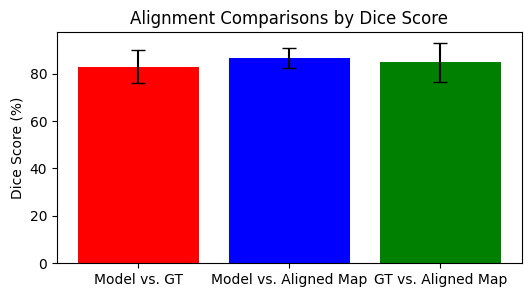

Elapsed Time: x̄ = 3.08 s, σ = 100 ms


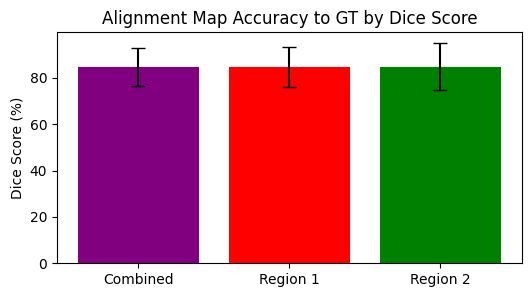

In [86]:
model_vs_gt = []
model_vs_map = []
gt_vs_map = []
dts = []
r1_scores = []
r2_scores = []
for r in result_scores:
    model_vs_gt.append(result_scores[r]["scores"][0])
    model_vs_map.append(result_scores[r]["scores"][1])
    gt_vs_map.append(result_scores[r]["scores"][2])
    r1_scores.append(result_scores[r]["regional"][0])
    r2_scores.append(result_scores[r]["regional"][1])
    dts.append(result_scores[r]["dt"])

means = [np.mean(model_vs_gt), 
         np.mean(model_vs_map), 
         np.mean(gt_vs_map)]

stds = [np.std(model_vs_gt), 
        np.std(model_vs_map), 
        np.std(gt_vs_map)]
fig, ax = plt.subplots(figsize=(6, 3))
plt.bar(["Model vs. GT", "Model vs. Aligned Map", "GT vs. Aligned Map"], means, yerr=stds, capsize=5, color=['red', 'blue', 'green'], ecolor='black')
plt.ylabel("Dice Score (%)")
plt.title("Alignment Comparisons by Dice Score")
plt.savefig(d / "Alignment Comparisons by Dice Score.png", dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()
print(f'Elapsed Time: x̄ = {np.mean(dts):.2f} s, σ = {np.std(dts)*1000:.0f} ms')

r_means = [np.mean(gt_vs_map),
           np.mean(r1_scores),
           np.mean(r2_scores)]
r_stds = [np.std(gt_vs_map),
          np.std(r1_scores),
          np.std(r2_scores)]
fig, ax = plt.subplots(figsize=(6, 3))
plt.bar(["Combined", "Region 1", "Region 2"], r_means, yerr=r_stds, capsize=5, color=['purple','red', 'green'], ecolor='black')
plt.ylabel("Dice Score (%)")
plt.title("Alignment Map Accuracy to GT by Dice Score")
plt.savefig(d / "Alignment Map Accuracy to GT by Dice Score.png", dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()

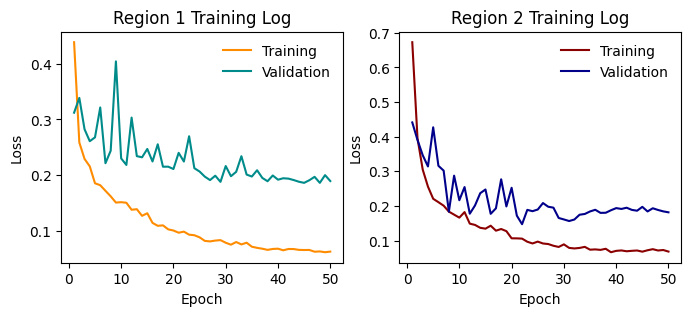

In [203]:
# Region 1: 50 Epochs
r1_train_loss = [
    0.438875, 0.258622, 0.229056, 0.215688, 0.185225, 0.181772, 0.171694, 0.161789, 0.150573, 0.151234,
    0.150229, 0.137637, 0.138621, 0.126726, 0.131359, 0.114020, 0.108768, 0.109557, 0.102373, 0.100324,
    0.096359, 0.098277, 0.092805, 0.091834, 0.088028, 0.081661, 0.080720, 0.082209, 0.083003, 0.078310,
    0.074807, 0.079620, 0.075322, 0.078362, 0.071191, 0.069108, 0.067583, 0.065502, 0.067123, 0.067608,
    0.064739, 0.067061, 0.066972, 0.065468, 0.065243, 0.065345, 0.062180, 0.062704, 0.061266, 0.062374
]

r1_val_loss = [
    0.312172, 0.338737, 0.282403, 0.260892, 0.267828, 0.321560, 0.221296, 0.243746, 0.404449, 0.229995,
    0.218186, 0.303364, 0.234039, 0.231965, 0.246945, 0.224443, 0.255355, 0.215025, 0.215107, 0.210881,
    0.239989, 0.224325, 0.269837, 0.212349, 0.206373, 0.197216, 0.190955, 0.198853, 0.187786, 0.216226,
    0.197935, 0.205828, 0.233924, 0.200888, 0.197372, 0.208679, 0.194892, 0.188903, 0.199238, 0.191713,
    0.194251, 0.193609, 0.191035, 0.188004, 0.185999, 0.190764, 0.196831, 0.185973, 0.199907, 0.189257
]

# Region 2: 50 Epochs
r2_train_loss = [
    0.672834, 0.395498, 0.305097, 0.256008, 0.220873, 0.211087, 0.200988, 0.183862, 0.175107, 0.166454,
    0.182432, 0.149094, 0.145423, 0.137071, 0.134597, 0.143153, 0.128831, 0.133601, 0.127486, 0.106751,
    0.106633, 0.105869, 0.096873, 0.091928, 0.097257, 0.091826, 0.090246, 0.085232, 0.081828, 0.089312,
    0.079138, 0.077513, 0.078994, 0.082080, 0.073939, 0.074769, 0.073354, 0.076572, 0.066616, 0.070549,
    0.071735, 0.069391, 0.070666, 0.071597, 0.068215, 0.072284, 0.075399, 0.071599, 0.072980, 0.068468
]

r2_val_loss = [
    0.441310, 0.390683, 0.346613, 0.314247, 0.427190, 0.316089, 0.302179, 0.183566, 0.287676, 0.216688,
    0.254687, 0.177792, 0.201628, 0.237012, 0.247666, 0.177454, 0.193358, 0.277162, 0.198778, 0.252682,
    0.172199, 0.147509, 0.188872, 0.185071, 0.189887, 0.208584, 0.197942, 0.195243, 0.165488, 0.161234,
    0.156672, 0.160991, 0.174886, 0.177057, 0.184308, 0.189138, 0.180202, 0.180545, 0.187758, 0.193964,
    0.191580, 0.195076, 0.188838, 0.186431, 0.197568, 0.184321, 0.193541, 0.188608, 0.184534, 0.181812
]

epochs = np.arange(0, 50)+1
fig, axes = plt.subplots(1,2,figsize=(8,3))
axes[0].plot(epochs, r1_train_loss, color='darkorange', label="Training")
axes[0].plot(epochs, r1_val_loss, color='darkcyan', label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Region 1 Training Log")
axes[0].legend(frameon=False)
axes[1].plot(epochs, r2_train_loss, color='darkred', label="Training")
axes[1].plot(epochs, r2_val_loss, color='darkblue', label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Region 2 Training Log")
axes[1].legend(frameon=False)
plt.savefig("training log.png", dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()

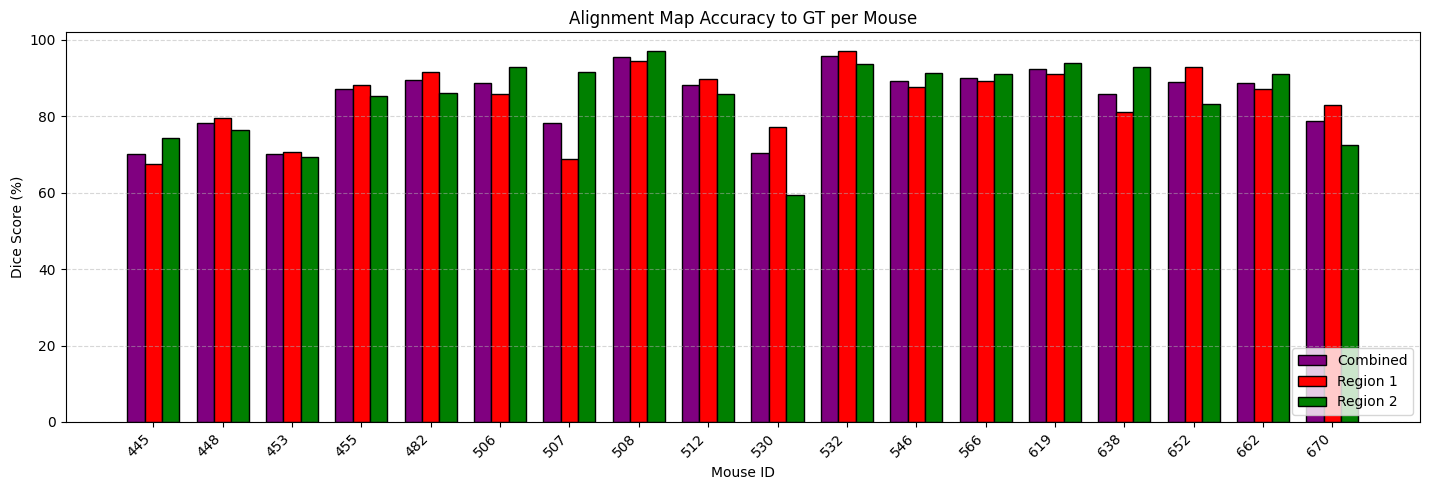

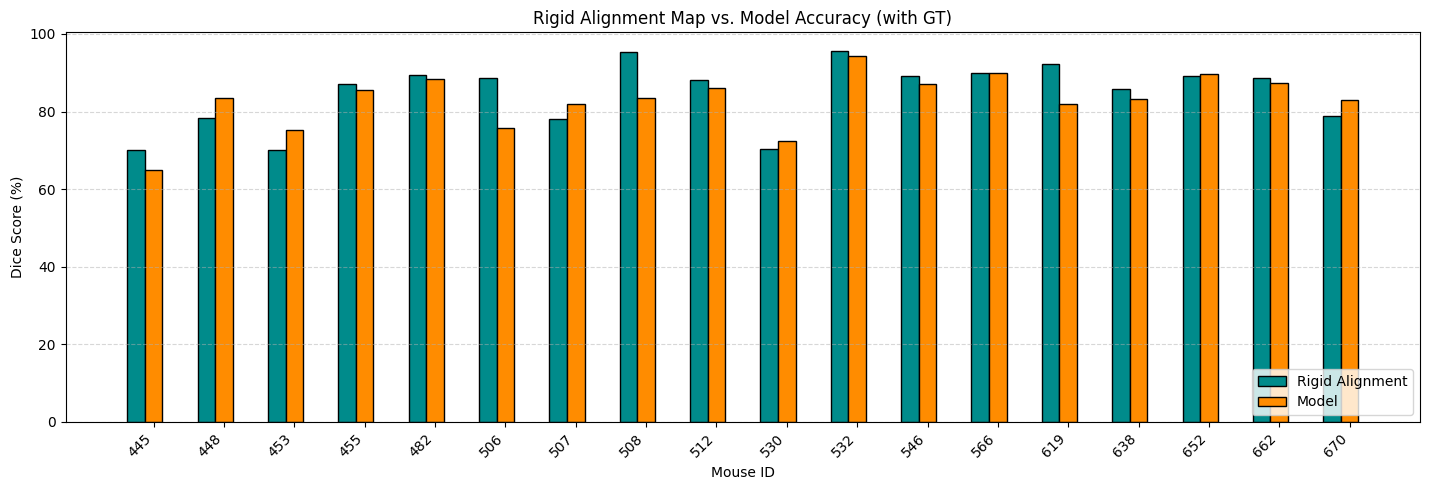

In [172]:
names = sorted(result_scores.keys())
x = np.arange(len(names))
width = 0.25
## alignment map
fig, ax = plt.subplots(figsize=(max(10, len(names)*0.8), 5))
rects1 = ax.bar(x - width, gt_vs_map, width, label='Combined', color='purple', edgecolor='black')
rects2 = ax.bar(x, r1_scores, width, label='Region 1', color='red', edgecolor='black')
rects3 = ax.bar(x + width, r2_scores, width, label='Region 2', color='green', edgecolor='black')

ax.set_ylabel('Dice Score (%)')
ax.set_xlabel('Mouse ID')
ax.set_title('Alignment Map Accuracy to GT per Mouse')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
#plt.savefig(d / "Alignment Map Accuracy to GT per Mouse.png", dpi=400, bbox_inches='tight', pad_inches=0)
#plt.show()

## model vs alignment
fig, ax = plt.subplots(figsize=(max(10, len(names)*0.8), 5))
rects1 = ax.bar(x - width, gt_vs_map, width, label='Rigid Alignment', color='darkcyan', edgecolor='black')
rects2 = ax.bar(x, model_vs_gt, width, label='Model', color='darkorange', edgecolor='black')

ax.set_ylabel('Dice Score (%)')
ax.set_xlabel('Mouse ID')
ax.set_title('Rigid Alignment Map vs. Model Accuracy (with GT)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(d / "Rigid Alignment Map vs. Model Accuracy (with GT).png", dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()

In [175]:
# significance test
from scipy import stats
import numpy as np

def compute_significance(raw_scores, aligned_scores):
    raw = np.array(raw_scores)
    aligned = np.array(aligned_scores)
    
    diff = aligned - raw
    
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    n = len(diff)
    se = std_diff / np.sqrt(n)
    
    t_stat = mean_diff / se
    _, p_val = stats.ttest_rel(aligned, raw)
    
    print(f"--- Paired t-test Results (N={n}) ---")
    print(f"Mean Improvement: {mean_diff:.2f}%")
    print(f"Standard Deviation of Diff: {std_diff:.2f}")
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value: {p_val:.4e}")
    
    if p_val < 0.05:
        print("Result: Statistically Significant (p < 0.05)")
    else:
        print("Result: Not Significant")
        
    return t_stat, p_val

compute_significance(model_vs_gt, gt_vs_map)

--- Paired t-test Results (N=18) ---
Mean Improvement: 1.75%
Standard Deviation of Diff: 5.45
T-Statistic: 1.3631
P-Value: 1.9063e-01
Result: Not Significant


(np.float64(1.3631216491602791), np.float64(0.19062718176441987))

In [169]:
# stats on all samples
worst = np.argmin(gt_vs_map)
best = np.argmax(gt_vs_map)
print(f'Worst: {names[worst]}, {gt_vs_map[worst]:.2f}%')
print(f'Best: {names[best]}, {gt_vs_map[best]:.2f}%')
print(f'Model: x̄ = {np.mean(model_vs_gt):.2f}%, σ = {np.std(model_vs_gt):.2f}%, q1 = {np.quantile(model_vs_gt, 0.25):.2f}%, q3 = {np.quantile(model_vs_gt, 0.75):.2f}%')
print(f'Alignment: x̄ = {np.mean(gt_vs_map):.2f}%, σ = {np.std(gt_vs_map):.2f}%, q1 = {np.quantile(gt_vs_map, 0.25):.2f}%, q3 = {np.quantile(gt_vs_map, 0.75):.2f}%')

Worst: 445, 70.13%
Best: 532, 95.62%
Model: x̄ = 82.95%, σ = 6.85%, q1 = 81.90%, q3 = 87.20%
Alignment: x̄ = 84.70%, σ = 8.09%, q1 = 78.38%, q3 = 89.35%


In [210]:
# separate samples by acccuracy
np.array(names)[np.array(gt_vs_map) < 80], np.array(names)[np.array(gt_vs_map) > 80]

(array(['445', '448', '453', '507', '530', '670'], dtype='<U3'),
 array(['455', '482', '506', '508', '512', '532', '546', '566', '619',
        '638', '652', '662'], dtype='<U3'))

In [85]:
# checking model runtime
d_total = {0:0, 1:0}
idx = 0
with open("gradient accumulation/training log.txt", "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")
    for line in lines:
        if "Training complete" in line:
            idx+=1
        if "<" in line:
            m, s = line.split("<")[0][-5:].split(":")
            d_total[idx] += int(m)*60 + int(s)
print(f'R1 Model: {d_total[0]/3600:.2f} hours\nR2 Model: {d_total[1]/3600:.2f} hours')

R1 Model: 2.26 hours
R2 Model: 2.33 hours


In [116]:
# figure generation for dataset
all_images = set(Path(str(s).lower()) for s in Path("dataset_split/Region2/images/").glob("*.png"))
validation_images=set()
with open("gradient accumulation/region2_validation_paths.txt", "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")
    for line in lines[1:]:
        validation_images.add(Path(line.lower()))
training_images = list(all_images - validation_images)
validation_images = list(validation_images)

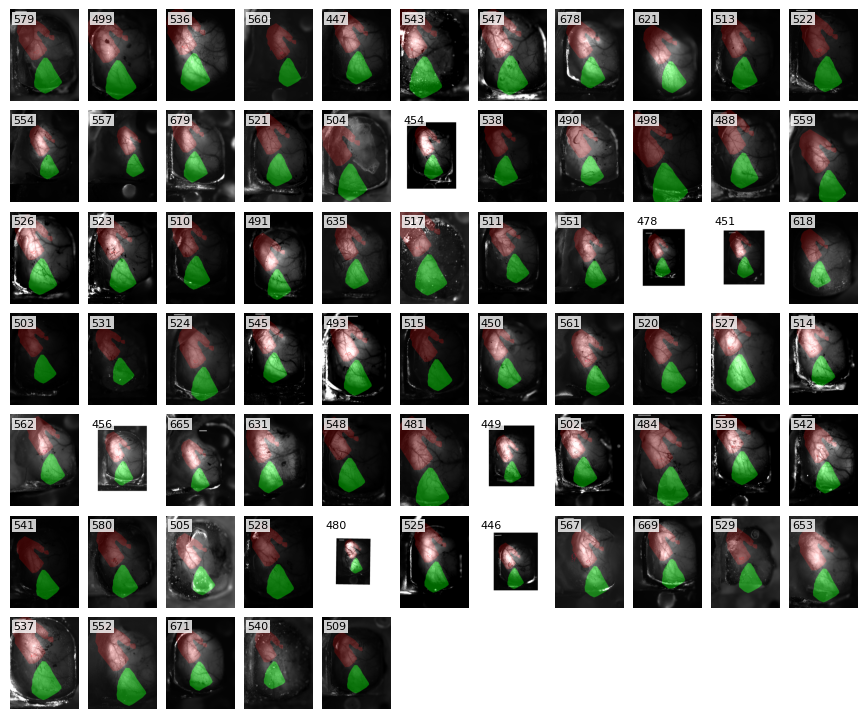

In [156]:
# figure generation continued
import matplotlib.image as mpimg

def grid(rows, cols, images):
    fig, axes = plt.subplots(rows, cols, figsize=(17, 14))
    
    current_img = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r,c]
            ax.axis('off')
            if current_img < len(images):
                img = cv.imread(images[current_img])
                r1 = cv.imread(Path(r"dataset_split\Region1\SegmentationClass") / images[current_img].name)
                r2 = cv.imread(Path(r"dataset_split\Region2\SegmentationClass") / images[current_img].name)
                r2[(r2 != [0, 0, 0]).any(axis=-1)] = (0, 255, 0)
                combined_overlay = cv.addWeighted(img, 1, r1, 0.4, 0)
                combined_overlay = cv.addWeighted(combined_overlay, 1, r2, 0.4, 0)
                
                ax.imshow(cv.cvtColor(combined_overlay, cv.COLOR_BGR2RGB))
                label = Path(images[current_img]).stem
                
                ax.text(
                    0.05, 0.95, label, 
                    transform=ax.transAxes, 
                    fontsize=8, 
                    verticalalignment='top',
                    horizontalalignment='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.0)
                )
                current_img += 1
    
    plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0, right=0.5, bottom=0, top=0.5)
    plt.savefig('training data.png', dpi=400, bbox_inches='tight', pad_inches=0)
    plt.show()

grid(7, 11, training_images)